### 1. Import Libraries 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# for the plots to appear inline in the notebook
%matplotlib inline

### 2. Assign Dataset

In [2]:
url = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'

### 3. Assign To Variable Apple

In [3]:
apple = pd.read_csv(url)
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### 4. Check Type of columns

In [4]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### 5. Transform the date column as datatime type

In [5]:
apple.Date = pd.to_datetime(apple['Date'])
apple['Date'].head()

0   2014-07-08
1   2014-07-07
2   2014-07-03
3   2014-07-02
4   2014-07-01
Name: Date, dtype: datetime64[us]

### 6. Set date as index

In [6]:
apple.Date = pd.to_datetime(apple['Date'])
apple['Date'].head()

0   2014-07-08
1   2014-07-07
2   2014-07-03
3   2014-07-02
4   2014-07-01
Name: Date, dtype: datetime64[us]

### 7. Is there any duplicate dates?


In [7]:
apple.index.is_unique

True

### 8. Make the first entry the oldest date

In [11]:
apple = apple.sort_index(ascending=True)
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### 9. Get the last day of each month

In [18]:
apple_month = apple.resample('BME').mean()
apple_month.head()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

###  10.  What is the difference in days between the first day and the oldest

In [13]:
(apple.index.max() - apple.index.min()).days

AttributeError: 'int' object has no attribute 'days'

In [14]:
(apple.index.max().year - apple.index.min().year) * 12 + (apple.index.max().month - apple.index.min().month)

AttributeError: 'int' object has no attribute 'year'

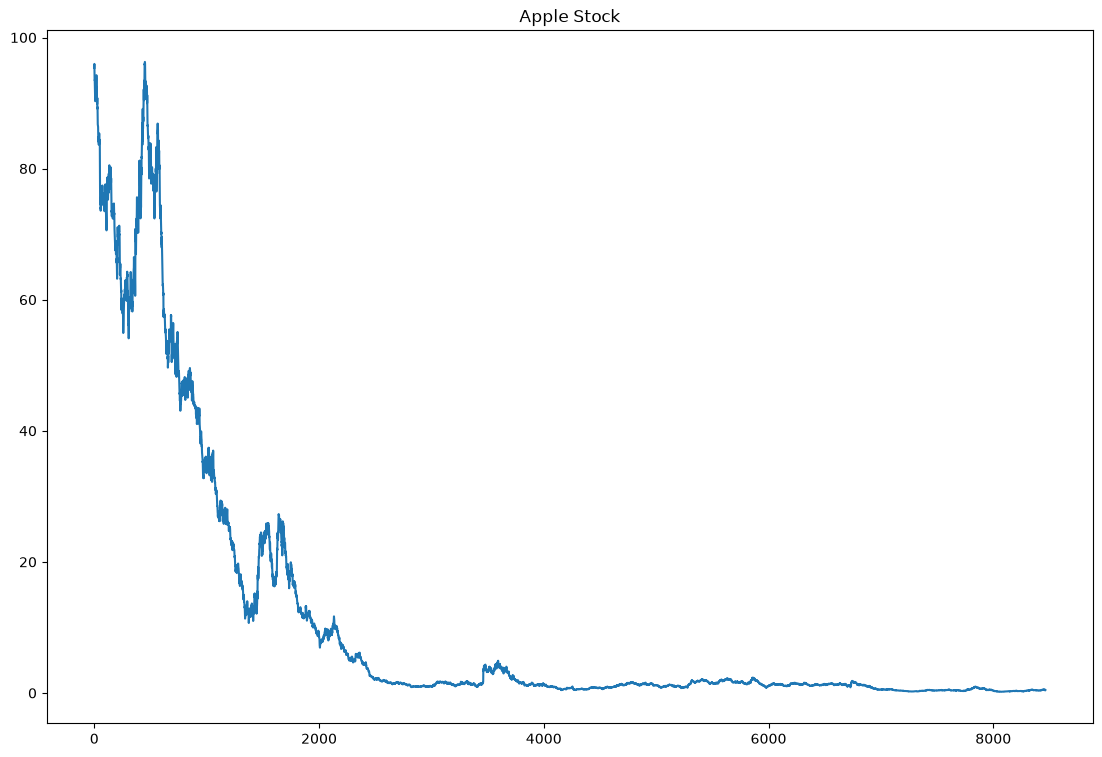

In [17]:
appl_open = apple['Adj Close'].plot(title='Apple Stock')
fig = appl_open.get_figure()
fig.set_size_inches(13.5, 9)

## Assignment 2

### 1. Import Necessary libraries 

In [19]:
import pandas as pd
import numpy as np

### 2. Assign to a variable called iris

In [20]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
iris = pd.read_csv(url, header=None)
iris.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### 3. Create columns

In [21]:
# 1. sepal_length (in cm)
# 2. sepal_width (in cm)
# 3. petal_length (in cm)
# 4. petal_width (in cm)
# 5. class

iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### 4. Is there any missing value?


In [22]:

iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

### 5.   set the values of the rows 10 to 29 of the column 'petal_length' to NaN

In [24]:
iris.loc[10:29, 'petal_length'] = np.nan
iris.isnull().sum()

sepal_length     0
sepal_width      0
petal_length    20
petal_width      0
class            0
dtype: int64

### 6.substitute the NaN values to 1.0

In [25]:
iris['petal_length'] = iris['petal_length'].fillna(1.0)
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

### 7. Delete column class

In [26]:
del iris['class']
iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 8. Set the first 3 rows as NaN

In [27]:
iris.iloc[0:3, :] = np.nan
iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 9. Delete the rows with NaN

In [28]:
iris = iris.dropna(how='any')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2


### 10. Reset the index to begin with 0

In [30]:
iris = iris.reset_index(drop=True)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,4.6,3.1,1.5,0.2
1,5.0,3.6,1.4,0.2
2,5.4,3.9,1.7,0.4
3,4.6,3.4,1.4,0.3
4,5.0,3.4,1.5,0.2
